In [1]:
import pandas as pd
import numpy as np
import keras
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

In [ ]:
dataset_df = pd.read_csv('../dataset/open-meteo_newDataset.csv')

In [3]:
dataset_df.head()

,time,temperature_2m (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),rain (mm),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),shortwave_radiation_instant (W/m²),direct_radiation_instant (W/m²),diffuse_radiation_instant (W/m²),direct_normal_irradiance_instant (W/m²),terrestrial_radiation_instant (W/m²)
0,2019-01-01T00:00,16.7,82,13.6,15.4,0.1,97,53,20,0,0.06,0.34,48.2,0.0,48.2,0.0,368.1
1,2019-01-01T01:00,17.2,85,14.6,16.0,0.1,100,100,42,0,0.08,0.30,128.6,16.1,112.5,46.1,609.9
2,2019-01-01T02:00,17.1,80,13.6,15.8,0.1,100,100,47,0,0.09,0.39,104.4,4.5,99.9,9.0,794.1
3,2019-01-01T03:00,18.0,77,14.0,16.6,0.0,100,100,43,0,0.14,0.47,187.5,7.4,180.1,12.2,908.4
4,2019-01-01T04:00,17.9,78,14.0,16.6,0.1,100,100,42,0,0.14,0.45,194.4,13.2,181.2,19.9,944.8


In [4]:
dataset_df.columns

Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'dew_point_2m (°C)', 'apparent_temperature (°C)', 'rain (mm)',
       'cloud_cover (%)', 'cloud_cover_low (%)', 'cloud_cover_mid (%)',
       'cloud_cover_high (%)', 'et0_fao_evapotranspiration (mm)',
       'vapour_pressure_deficit (kPa)', 'shortwave_radiation_instant (W/m²)',
       'direct_radiation_instant (W/m²)', 'diffuse_radiation_instant (W/m²)',
       'direct_normal_irradiance_instant (W/m²)',
       'terrestrial_radiation_instant (W/m²)'],
      dtype='object')

In [5]:
dataset_df['time'] = pd.to_datetime(dataset_df['time'])
dataset_df['month'] = dataset_df['time'].dt.month

# Pisahkan data berdasarkan bulan
january_df = dataset_df[dataset_df['month'] == 1]
february_df = dataset_df[dataset_df['month'] == 2]
march_df = dataset_df[dataset_df['month'] == 3]
april_df = dataset_df[dataset_df['month'] == 4]
may_df = dataset_df[dataset_df['month'] == 5]
june_df = dataset_df[dataset_df['month'] == 6]
july_df = dataset_df[dataset_df['month'] == 7]
august_df = dataset_df[dataset_df['month'] == 8]
september_df = dataset_df[dataset_df['month'] == 9]
october_df = dataset_df[dataset_df['month'] == 10]
november_df = dataset_df[dataset_df['month'] == 11]
december_df = dataset_df[dataset_df['month'] == 12]

In [6]:
january_df.set_index('time', inplace=True)
february_df.set_index('time', inplace=True)
march_df.set_index('time', inplace=True)
april_df.set_index('time', inplace=True)
may_df.set_index('time', inplace=True)
june_df.set_index('time', inplace=True)
july_df.set_index('time', inplace=True)
august_df.set_index('time', inplace=True)
september_df.set_index('time', inplace=True)
october_df.set_index('time', inplace=True)
november_df.set_index('time', inplace=True)
december_df.set_index('time', inplace=True)

# January

## Preprocessing

In [7]:
data_features = january_df[['shortwave_radiation_instant (W/m²)', 'direct_radiation_instant (W/m²)',
       'direct_normal_irradiance_instant (W/m²)', 'temperature_2m (°C)', 'et0_fao_evapotranspiration (mm)',
       'vapour_pressure_deficit (kPa)','apparent_temperature (°C)', 'cloud_cover (%)',
       'cloud_cover_low (%)', 'cloud_cover_mid (%)', 'terrestrial_radiation_instant (W/m²)', 'dew_point_2m (°C)']].values
data_target = january_df['shortwave_radiation_instant (W/m²)'].values

In [8]:
print(len(data_features))

744


In [9]:
look_back = 24 #menggunakan timestamp 24
n_ahead = 24 # predict 24 jam berikutnya

x_seq = []
y_seq = []

for i in range(len(data_features) - look_back - n_ahead + 1):
    x_seq.append(data_features[i : (i + look_back)]) # mengambil value 24 jam sebelum
    y_seq.append(data_target[(i + look_back) : (i + look_back + n_ahead)]) #mengambil value 24 jam berikutnya

x_seq, y_seq = np.array(x_seq), np.array(y_seq)

In [10]:
print(x_seq.shape)
print(y_seq.shape)

(697, 24, 12)
(697, 24)


In [11]:
split_point = int(len(x_seq) * 0.8) # 80% for training and 20% for testing

x_train, x_test = x_seq[:split_point], x_seq[split_point:]
y_train, y_test = y_seq[:split_point], y_seq[split_point:]

#flatten the y

y_train = y_train.flatten()
y_test = y_test.flatten()

print(f'x_train shape: {x_train.shape}, x_test shape: {x_test.shape}')
print(f'y_train shape: {y_train.shape}, y_test shape: {y_test.shape}')

x_train shape: (557, 24, 12), x_test shape: (140, 24, 12)
y_train shape: (13368,), y_test shape: (3360,)


In [12]:
from sklearn.preprocessing import StandardScaler, RobustScaler

scaler_x = RobustScaler()
scaler_y = RobustScaler()

#fit dan transform the training data
#kalau mau fit transform, data harus 2 dimensi. untuk x, kembalikan ke 3 dimensi. untuk y, kembalikan 1 dimensi
x_train_scaled = scaler_x.fit_transform(x_train.reshape(-1, x_train.shape[2])).reshape(x_train.shape[0], x_train.shape[1], x_train.shape[2]) 
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, n_ahead))
# y_train_scaled = y_train_scaled.flatten()

# tranform the testing data
x_test_scaled = scaler_x.fit_transform(x_test.reshape(-1, x_train.shape[2])).reshape(x_test.shape[0], x_test.shape[1], x_train.shape[2])
y_test_scaled = scaler_y.transform(y_test.reshape(-1, n_ahead))
# y_test_scaled = y_test_scaled.flatten()

# # Reshape X_train and X_test to 3D for LSTM input (samples, time steps, features)
# X_train_scaled = X_train.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
# X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Check the shapes after standardization
print(f'X_train_scaled shape: {x_train_scaled.shape}, X_test_scaled shape: {x_test_scaled.shape}')
print(f'y_train_scaled shape: {y_train_scaled.shape}, y_test_scaled shape: {y_test_scaled.shape}')

X_train_scaled shape: (557, 24, 12), X_test_scaled shape: (140, 24, 12)
y_train_scaled shape: (557, 24), y_test_scaled shape: (140, 24)


## Build Model

In [13]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    x = keras.layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = keras.layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

In [14]:
class ExpandDims(keras.layers.Layer):
    def __init__(self, axis, **kwargs):
        super(ExpandDims, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.expand_dims(inputs, axis=self.axis)

In [15]:
def build_model(
    n_input,
    n_output,
    num_features,
    head_size,
    num_heads,
    ff_dim,
    num_transformer_blocks,
    mlp_units,
    dropout=0,
    mlp_dropout=0,
):
    inputs = keras.Input(shape=(n_input, num_features))
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)

    # x = keras.layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    # x = ExpandDims(axis=1)(x)
    print(x.shape)
    
    # taruh LSTM disini
    x = keras.layers.LSTM(units=32, name="lstm_encoder_hidden", return_sequences=True, 
                        kernel_initializer='he_normal',
                        kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = keras.layers.Dropout(0.25)(x)
    x, state_h, state_c = keras.layers.LSTM(units=32, return_state=True, return_sequences=True, 
                                          name="lstm_encoder")(x)

    x = keras.layers.LSTM(units=32, return_sequences=True, name="lstm_decoder")(x, initial_state=[state_h, state_c])    
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.LSTM(units=32, name="lstm_decoder_final", return_sequences=False)(x)

    for dim in mlp_units:
        x = keras.layers.Dense(dim, activation="relu")(x)
        x = keras.layers.Dropout(mlp_dropout)(x)

    outputs = keras.layers.Dense(n_output, activation="linear")(x)
    return keras.Model(inputs, outputs)


## Train and Evaluate

In [16]:
model = build_model(
    n_input=look_back,
    n_output=n_ahead,
    num_features=x_train_scaled.shape[2],
    head_size=256,
    num_heads=4,
    ff_dim=4,
    num_transformer_blocks=4,
    mlp_units=[128],
    mlp_dropout=0.4,
    dropout=0.25,
)

model.compile(
    loss="mean_squared_error",
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=["accuracy"],
)
model.summary()

callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True) ]

model.fit(
    x_train_scaled,
    y_train_scaled,
    validation_split=0.2,
    epochs=50,
    batch_size=50,
    callbacks=callbacks,
)

model.evaluate(x_test_scaled, y_test_scaled, verbose=1)

(None, 24, 12)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 24, 12)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention      │ (None, 24, 12)         │         52,236 │ input_layer[0][0],     │
│ (MultiHeadAttention)      │                        │                │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 24, 12)         │              0 │ multi_head_attention[… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization       │ (None, 24, 12)         │             24 │ dropout_1[0][0]        │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 24, 12)         │              0 │ layer_normalization[0… │
│                           │                        │                │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d (Conv1D)           │ (None, 24, 4)          │             52 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 24, 4)          │              0 │ conv1d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_1 (Conv1D)         │ (None, 24, 12)         │             60 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_1     │ (None, 24, 12)         │             24 │ conv1d_1[0][0]         │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_1 (Add)               │ (None, 24, 12)         │              0 │ layer_normalization_1… │
│                           │                        │                │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multi_head_attention_1    │ (None, 24, 12)         │         52,236 │ add_1[0][0],           │
│ (MultiHeadAttention)      │                        │                │ add_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_4 (Dropout)       │ (None, 24, 12)         │              0 │ multi_head_attention_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ layer_normalization_2     │ (None, 24, 12)         │             24 │ dropout_4[0][0]        │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_2 (Add)               │ (None, 24, 12)         │              0 │ layer_normalization_2… │
│                           │                        │                │ add_1[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_2 (Conv1D)         │ (None, 24, 4)          │             52 │ add_2[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_5 (Dropout)  

 Total params: 247,688 (967.53 KB)

 Trainable params: 247,688 (967.53 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 23s 381ms/step - accuracy: 0.0566 - loss: 4.0706 - val_accuracy: 0.0625 - val_loss: 4.9369
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - accuracy: 0.0468 - loss: 4.0138 - val_accuracy: 0.0536 - val_loss: 4.8829
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step - accuracy: 0.0453 - loss: 4.1101 - val_accuracy: 0.0536 - val_loss: 4.8337
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.0342 - loss: 3.9718 - val_accuracy: 0.0357 - val_loss: 4.7789
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.0399 - loss: 3.8765 - val_accuracy: 0.0268 - val_loss: 4.7221
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 198ms/step - accuracy: 0.0497 - loss: 3.8094 - val_accuracy: 0.0357 - val_loss: 4.6670
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.0422 - loss: 3.8715 - val_accuracy: 0.0536 - val_loss: 4.6136
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - accuracy: 0.0436 - loss: 3.8538 - val_accuracy: 0.0625 - val_loss

[4.440054893493652, 0.1785714328289032]

## Predict

In [17]:
# Make predictions on the test set
y_pred_scaled = model.predict(x_test_scaled)

# De-standardize the predictions using the same scaler as for y
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

# De-standardize the actual values
y_test = scaler_y.inverse_transform(y_test_scaled).flatten()

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step


In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')

Mean Absolute Error (MAE): 118.57193038970865
Mean Squared Error (MSE): 38019.68260715821


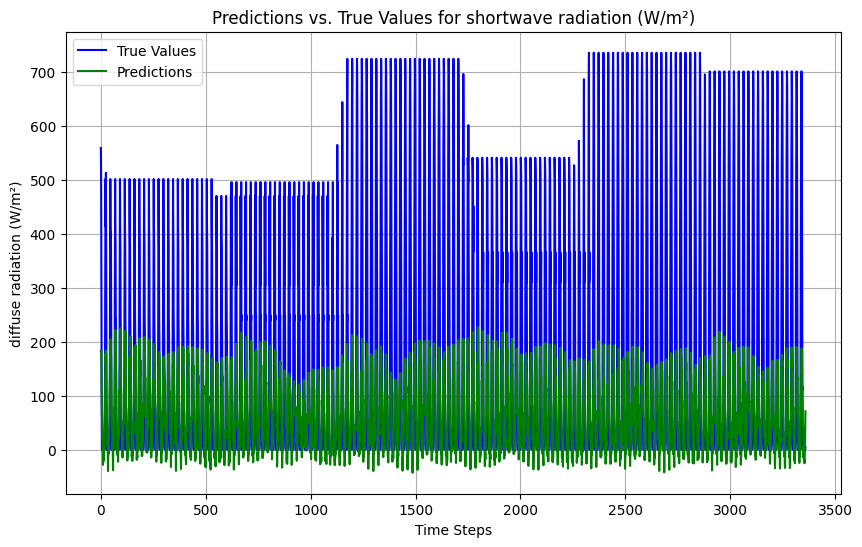

In [21]:
# prompt: plot the prediction vs true test

# Plot the predictions vs. true values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='True Values', color='blue')
plt.plot(y_pred, label='Predictions', color='green')
plt.title('Predictions vs. True Values for shortwave radiation (W/m²)')
plt.xlabel('Time Steps')
plt.ylabel('diffuse radiation (W/m²)')
plt.legend()
plt.grid(True)
plt.show()

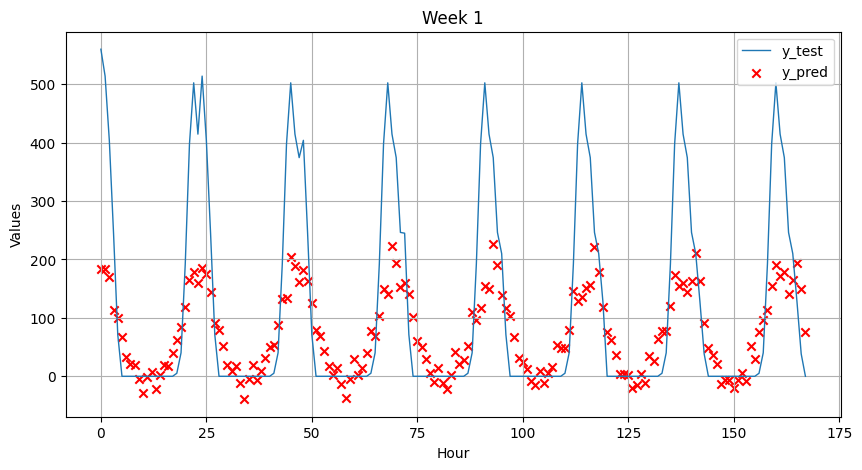

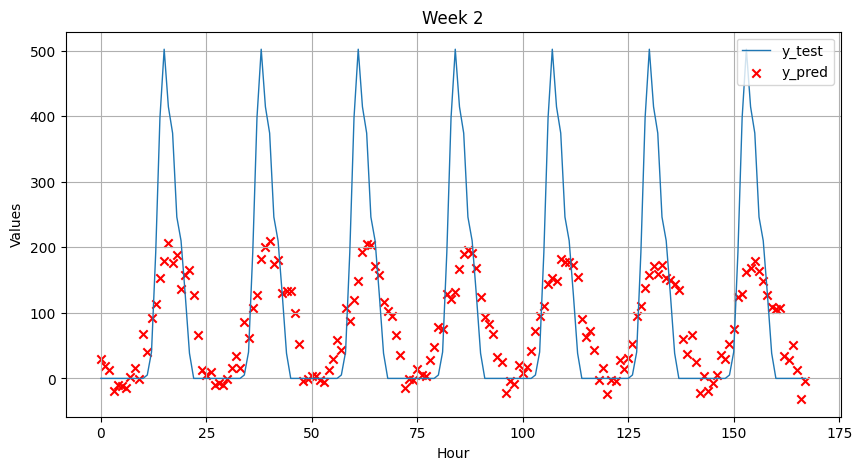

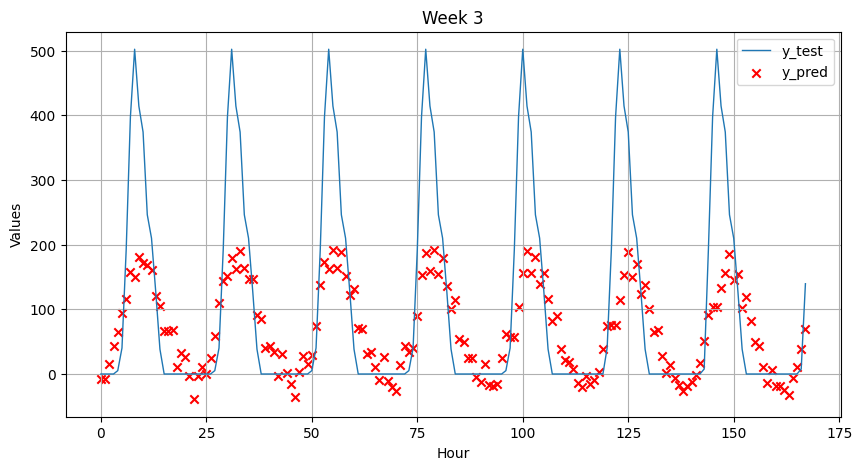

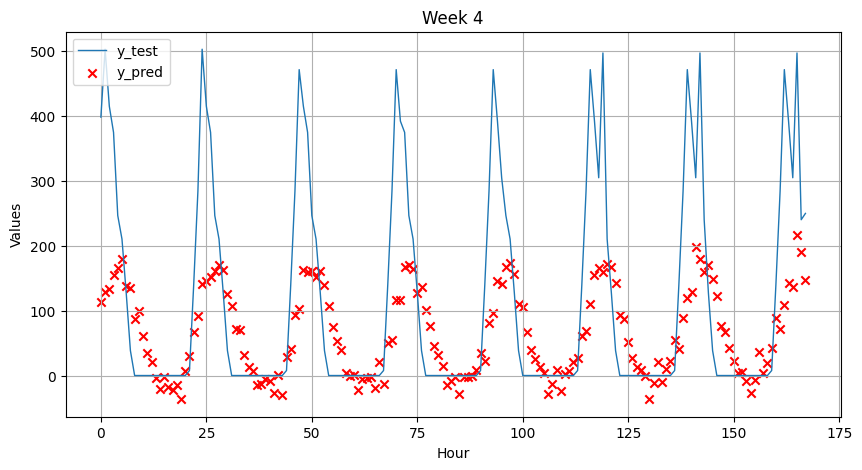

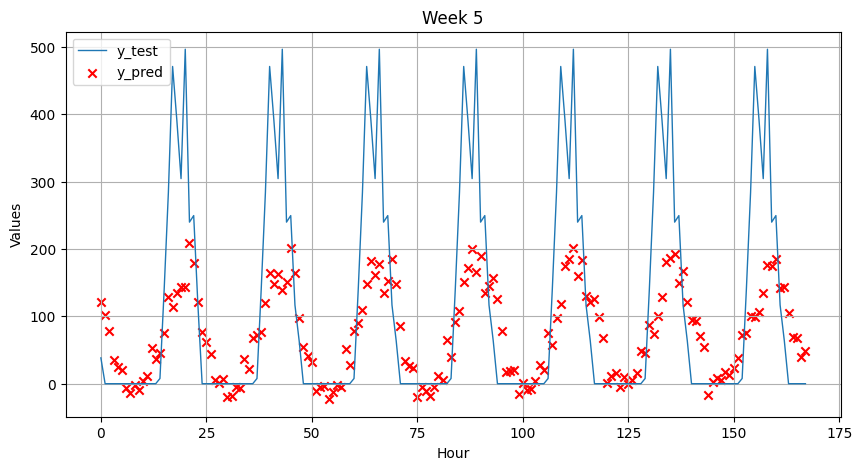

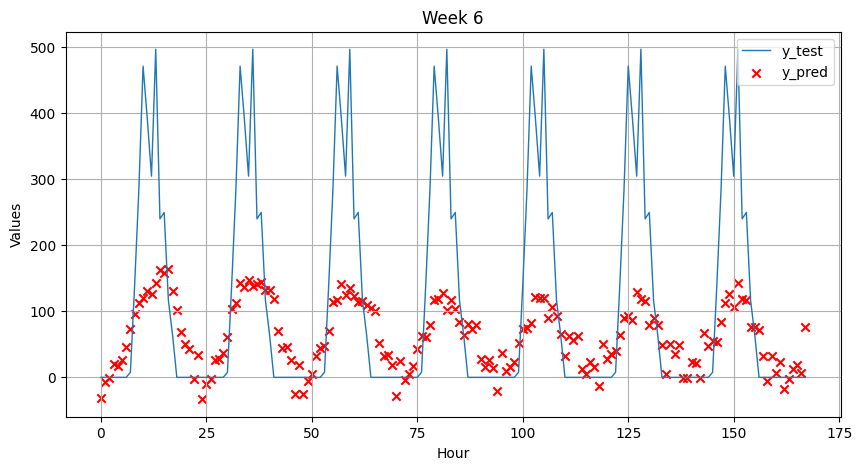

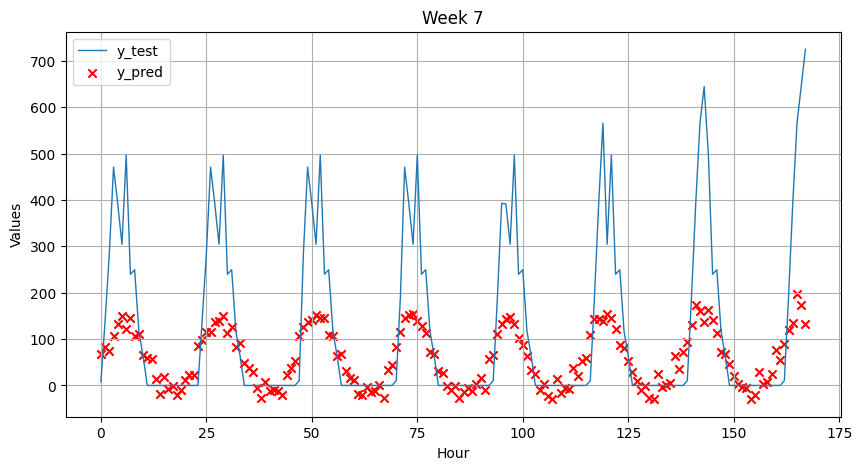

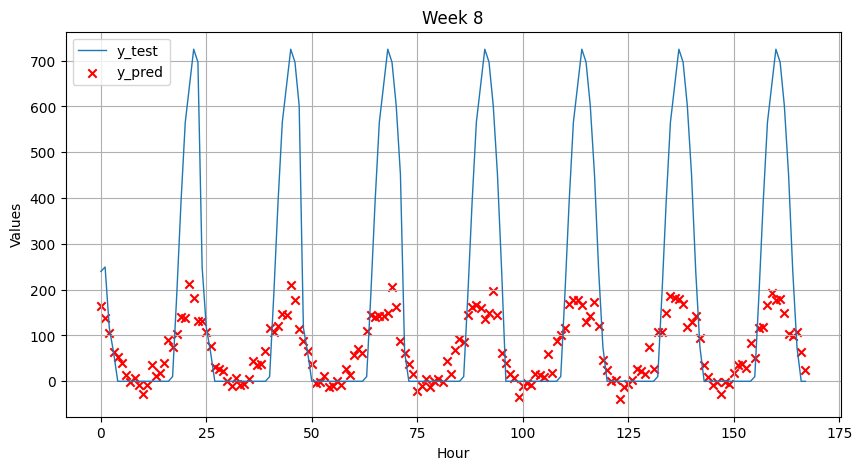

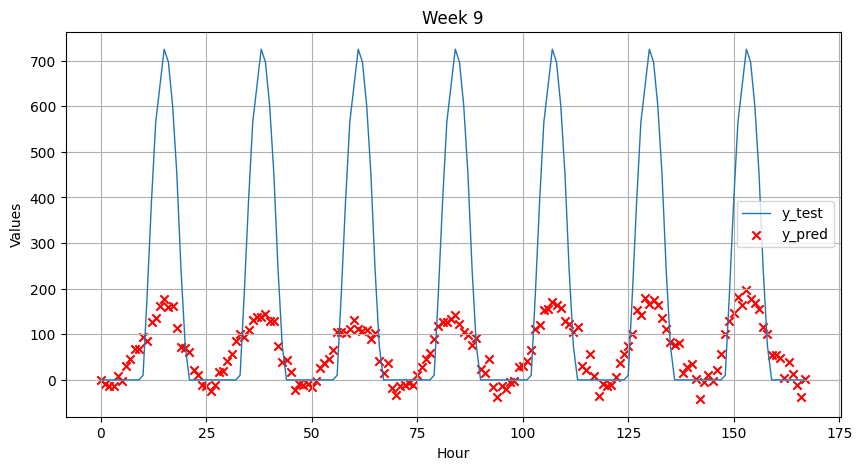

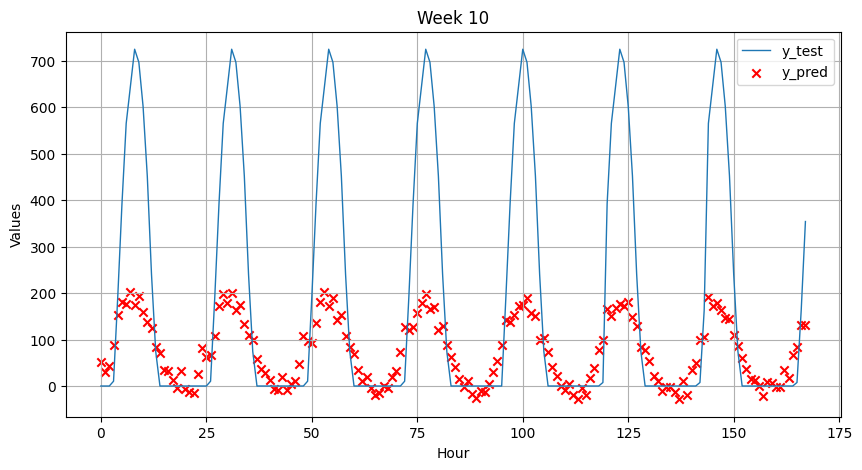

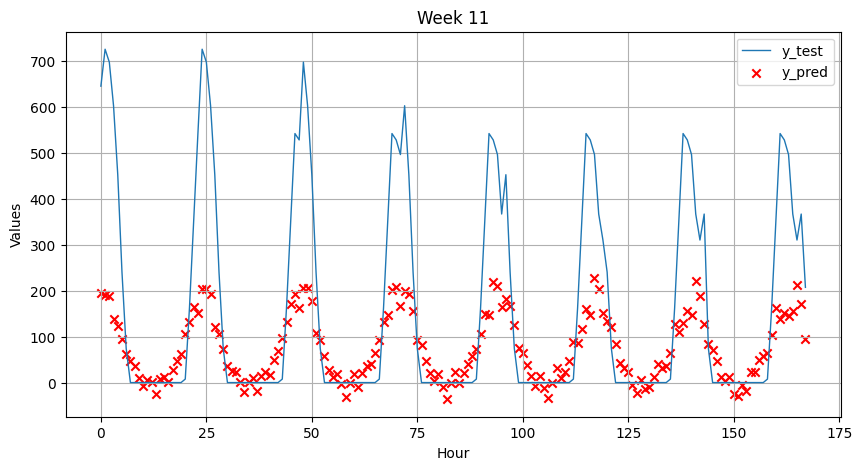

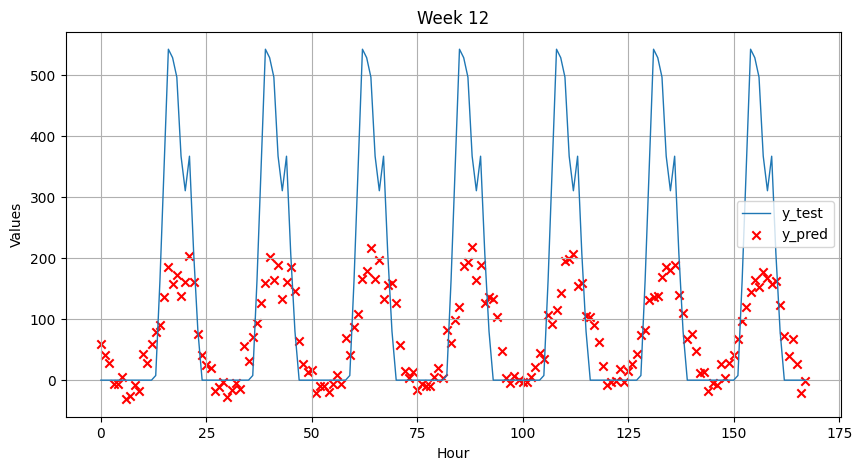

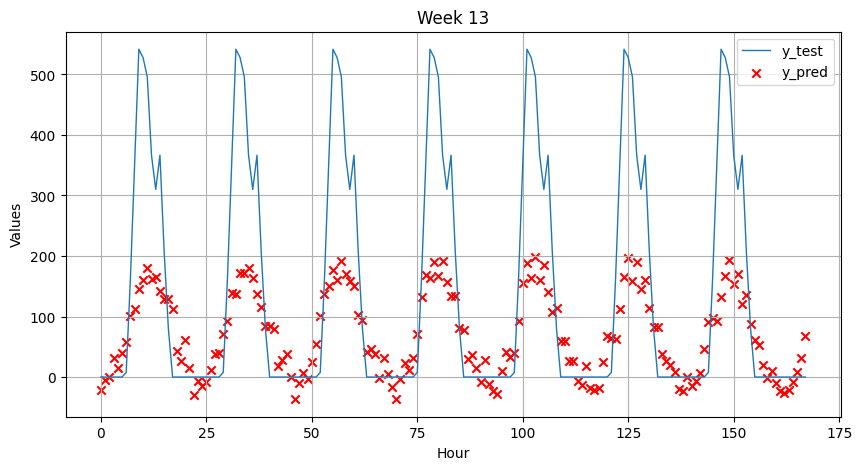

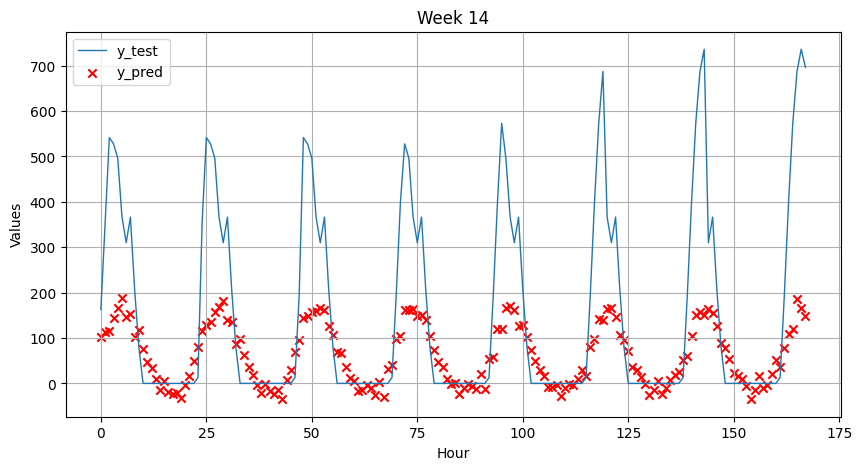

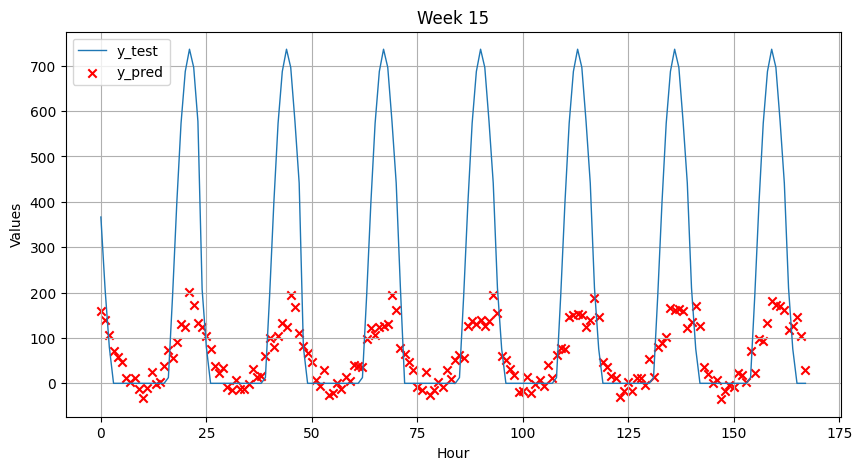

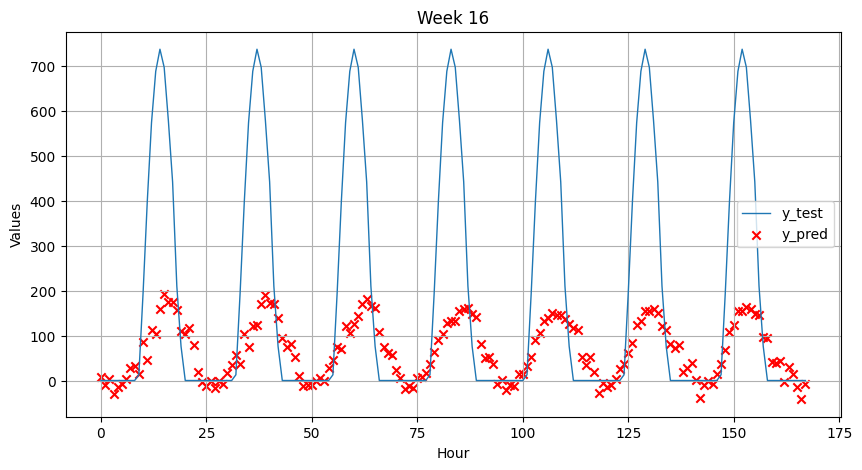

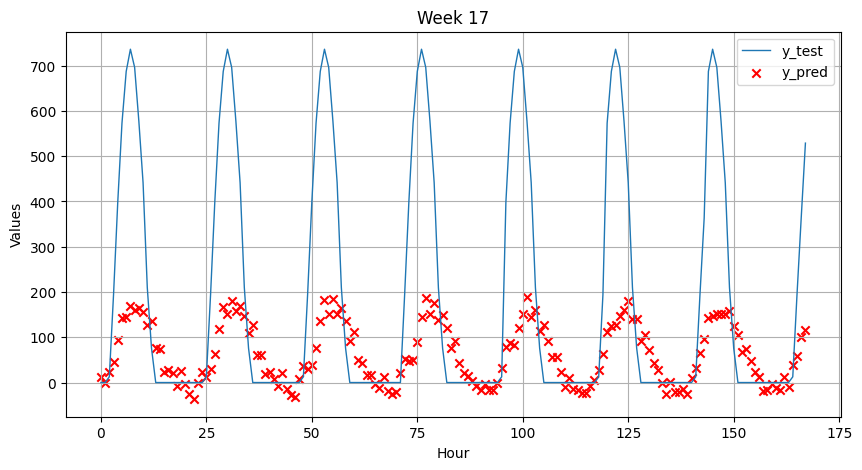

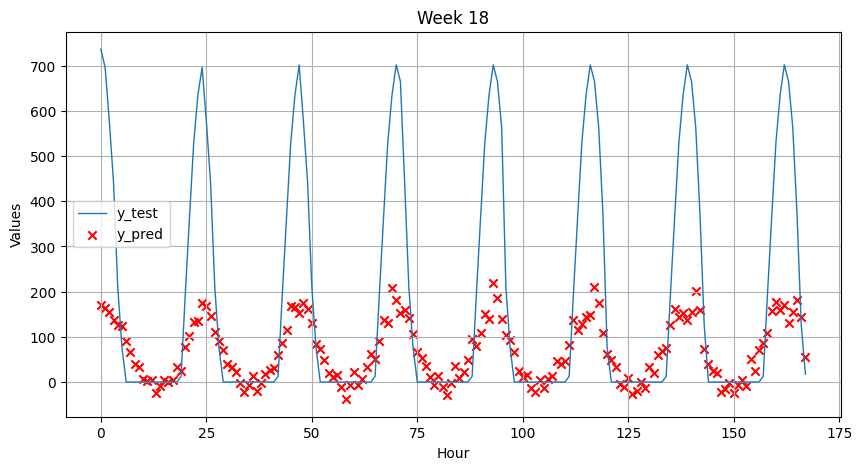

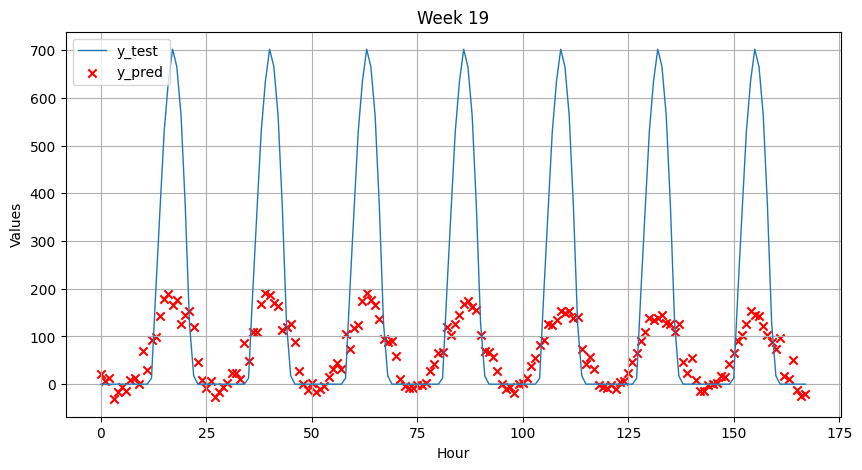

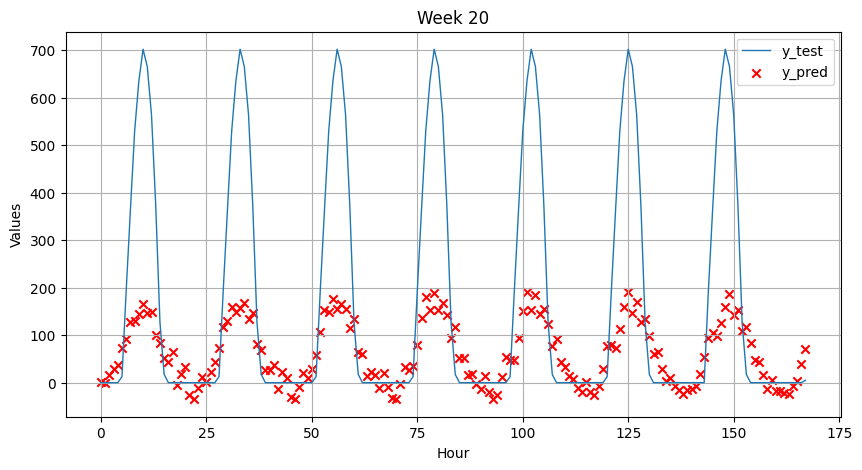

In [20]:
hours_per_week = 24 * 7

num_weeks = len(y_pred) // hours_per_week

for week in range(num_weeks):
    start_idx = week * hours_per_week
    end_idx = start_idx + hours_per_week
    plt.figure(figsize=(10, 5))  # Set ukuran figure
    plt.plot(y_test[start_idx:end_idx], label='y_test', linewidth=1)
    plt.scatter(range(hours_per_week), y_pred[start_idx:end_idx], color='red', marker='x', label='y_pred')
    plt.title(f'Week {week + 1}')
    plt.xlabel('Hour')
    plt.ylabel('Values')
    plt.legend()
    plt.grid(True)
    plt.show()